# 01 — Electrical Operating Envelope & Power Budget

**Project:** USB-C PD → 12 V fan-array controller (LM5176 4-switch buck-boost, 42 W)

**Purpose:** Turn the load and mission profile of notebook 00 into the converter's
electrical operating envelope — the input voltage and current the source guarantees, the
output power reachable at each, the buck/boost mode map, and the inductor and switch
currents that notebooks 03–06 size against — then state the loss budget at the points that
matter and compare it with what the built board measures.

**Design basis (V1):** USB-C PD source, 5–20 V, 3 A standard contracts (5 A only with an
e-marked cable); V_out = 12 V; f_sw = 100 kHz; L = 47 µH (Würth 7443634700); load is up to
ten Arctic P14 Pro plus a 5 V housekeeping buck.

**Key result — decision:** on a 3 A contract the envelope is **input-current-limited below
14.6 V and load-limited above it** (12.3 V against the measured load). The binding corner
is 5 V / 3 A: 15 W in from a stiff 5.00 V, measured as 13.63 W out from a bench supply that
sagged to 4.64 V — the mission profile's 67 % "high" setting, but not full speed. That
corner is Objective 1. Above 15 V the source has more power than the fans can absorb, so
higher PD voltages are checked, not optimized. Sizing uses the 42.7 W nameplate load (19 %
above the 35.9 W measured in notebook 00), which keeps every saturation, ripple and thermal
margin downstream conservative.

A second result falls out of the measured loss table: **at the quiet setting — 95 % of
operating hours — 9 V is the most efficient PD contract and 20 V the least.** The
difference is small in absolute terms but free to take.

Measured loss at the 5 V corner is **0.39 W (η = 97.2 %)**, itemised in §4 against the
component models of notebooks 03 and 04, which together account for 66 % of it.

**Caveat inherited from notebook 00:** the mission-profile power levels used in §4 were
measured with the fans in open air, not in the finished enclosure. The converter
efficiency numbers are unaffected — they are measured at whatever load was present — but
which output power corresponds to "quiet" or "high" may shift.

**See also:** 00 (where the load and mission profile come from), 03 (inductor), 04
(MOSFETs), 05 (capacitors — the C_out ESR estimate lives there, not here), 06 (ripple),
07 (loop and sense resistor), 11 (measured vs modeled loss).

## 1. What a USB-C source actually guarantees

Two limits define the input, and they are not independent — PD sources advertise fixed
voltage/current pairs (PDOs), and the current allowance varies per voltage.

- **Voltage.** Only 5 V is mandatory. 9 V, 15 V and 20 V appear on sources above 15 W, but
  a source is free to offer any subset. **12 V is not a required PD voltage**, which is
  why this board converts rather than using a 12 V trigger (notebook 00).
- **Current.** 3 A is the ceiling on a standard cable; 5 A needs an e-marked cable and a
  source that advertises it. V1 is designed for 3 A and checked at 5 A.
- **Tolerance.** `constants.USB` carries a ±10 % project design margin, wider than the PD
  spec itself (±5 % steady-state plus ±0.5 V during transitions, i.e. 21.5 V worst case on
  a 20 V contract). The wider margin is what the input-side voltage ratings are chosen
  against.

In [1]:
import sys; sys.path.insert(0, '..')                                   # repo root: constants.py
sys.path.insert(0, '../measurements/test setup/efficiency_esp32')      # efficiency analysis tools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import constants as cfg
from calibrate_shunts import load_calibration
from plot_efficiency import load

pd.set_option('display.width', 200)

V_OUT = cfg.FAN.V_NOMINAL
F_SW  = cfg.DESIGN.F_SW_HZ
L     = 47e-6                       # Wuerth 7443634700, notebook 03

# --- input envelope ---
V_IN_LO = cfg.USB.V_MIN * (1 - cfg.USB.V_TOLERANCE)                  # 4.5 V, project margin
V_IN_HI = cfg.USB.V_MAX * (1 + cfg.USB.V_TOLERANCE)                  # 22.0 V, project margin
V_PD_WORST = cfg.USB.V_MAX * (1 + cfg.USB.V_PD_NEW_TOL) + cfg.USB.V_PD_VALID_ADD   # 21.5 V, PD spec
v_in = np.linspace(V_IN_LO, V_IN_HI, 400)

I_STD  = cfg.USB.I_MAX_STANDARD        # 3 A, standard cable
I_HIGH = cfg.USB.I_MAX_HIGH_POWER      # 5 A, e-marked cable

# --- load ceiling ---
NAMEPLATE_FANS_W = cfg.MAX_FAN_LOAD_WATTS            # 10 x 0.35 A x 12 V = 42 W, sizing basis
MEASURED_FANS_W  = 35.44                             # notebook 00, 100 % PWM, measured
HOUSEKEEPING_W   = 0.44                              # notebook 00, 5 V buck input, measured
LOAD_SIZING_W    = cfg.TOTAL_MAX_LOAD_WATTS          # nameplate fans + logic estimate
LOAD_MEASURED_W  = MEASURED_FANS_W + HOUSEKEEPING_W

print(f"Input voltage, project margin (+/-10 %) : {V_IN_LO:.2f} - {V_IN_HI:.2f} V")
print(f"Input voltage, PD spec worst case       : up to {V_PD_WORST:.2f} V on a 20 V contract")
print(f"Input current                           : {I_STD:.0f} A standard, {I_HIGH:.0f} A e-marked\n")
print(f"Load, sizing basis (nameplate)          : {LOAD_SIZING_W:.2f} W  <- used by notebooks 03-06")
print(f"Load, measured at 100 % PWM (nb 00)     : {LOAD_MEASURED_W:.2f} W")
print(f"  sizing basis is {100*(LOAD_SIZING_W/LOAD_MEASURED_W - 1):.0f} % above the measured load")

Input voltage, project margin (+/-10 %) : 4.50 - 22.00 V
Input voltage, PD spec worst case       : up to 21.50 V on a 20 V contract
Input current                           : 3 A standard, 5 A e-marked

Load, sizing basis (nameplate)          : 42.73 W  <- used by notebooks 03-06
Load, measured at 100 % PWM (nb 00)     : 35.88 W
  sizing basis is 19 % above the measured load


## 2. The operating envelope

Output power is the lesser of what the source can deliver and what the fans can absorb.
The crossover is the only interesting feature: below it the design is power-starved and
efficiency buys capability; above it there is spare source power and efficiency only buys
electricity.

Measured efficiency is used rather than assumed, from the four 2026-09-15 runs.

In [2]:
MEAS = '../measurements/efficiency/'
CAL  = [MEAS + '2026-09-15_133151_shunt_cal_in.csv',
        MEAS + '2026-09-15_154613_shunt_cal_fan12.csv::b5in']
RUNS = {5:  '2026-09-15_151555_fans_5V.csv',  9:  '2026-09-15_151955_fans_9V.csv',
        15: '2026-09-15_141025_fans_15V.csv', 20: '2026-09-15_141459_fans_20V.csv'}
cal  = load_calibration(CAL)
runs = {v: load(MEAS + f, cal)[1] for v, f in RUNS.items()}

ETA_NOM = 0.975      # representative of the measured band (96.8-98.8 %) for the envelope lines

p_src_std  = v_in * I_STD
p_src_high = v_in * I_HIGH
p_out_std  = np.minimum(LOAD_SIZING_W, p_src_std * ETA_NOM)
p_out_high = np.minimum(LOAD_SIZING_W, p_src_high * ETA_NOM)

v_cross_std  = LOAD_SIZING_W / (I_STD * ETA_NOM)
v_cross_high = LOAD_SIZING_W / (I_HIGH * ETA_NOM)
print(f"Source/load crossover, 3 A contract: {v_cross_std:.1f} V")
print(f"Source/load crossover, 5 A contract: {v_cross_high:.1f} V")
print(f"  (against the measured {LOAD_MEASURED_W:.1f} W load: "
      f"{LOAD_MEASURED_W/(I_STD*ETA_NOM):.1f} V and {LOAD_MEASURED_W/(I_HIGH*ETA_NOM):.1f} V)\n")

# What each measured run actually reached
rows = []
for v, act in runs.items():
    k = act.P_in.idxmax()
    rows.append({'V_nominal': v, 'V_in_at_max': round(act.loc[k, 'in_V'], 2),
                 'I_in_max_A': round(act.loc[k, 'in_A'], 2), 'P_in_max_W': round(act.loc[k, 'P_in'], 2),
                 'P_out_max_W': round(act.loc[k, 'P_out'], 2), 'eta': round(act.loc[k, 'eta'], 3),
                 'PWM_max_pct': round(act.loc[k, 'pwm_pct'], 0),
                 'eta_peak': round(act.eta.max(), 3)})
reached = pd.DataFrame(rows)
print(reached.to_string(index=False))
print("\nThe 5 V and 9 V runs were stopped by the 3 A input limit; 15 V and 20 V by the fans.")

Source/load crossover, 3 A contract: 14.6 V
Source/load crossover, 5 A contract: 8.8 V
  (against the measured 35.9 W load: 12.3 V and 7.4 V)

 V_nominal  V_in_at_max  I_in_max_A  P_in_max_W  P_out_max_W   eta  PWM_max_pct  eta_peak
         5         4.64        3.02       14.02        13.63 0.972         64.0     0.977
         9         8.74        3.02       26.35        25.92 0.984         86.0     0.990
        15        14.68        2.55       37.41        36.89 0.986         99.0     0.993
        20        19.93        1.88       37.38        36.78 0.984         99.0     0.986

The 5 V and 9 V runs were stopped by the 3 A input limit; 15 V and 20 V by the fans.


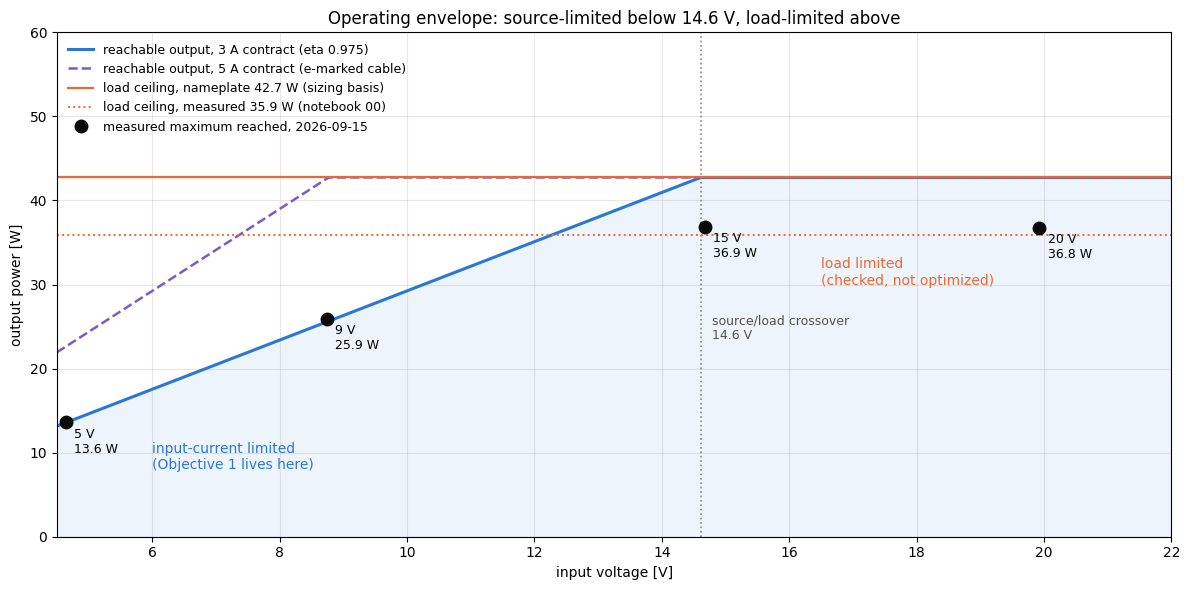

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(v_in, 0, p_out_std, color='#2a78d6', alpha=0.08)
ax.plot(v_in, p_out_std,  lw=2.2, color='#2a78d6', label=f'reachable output, 3 A contract (eta {ETA_NOM:.3f})')
ax.plot(v_in, p_out_high, lw=1.8, color='#7a5cc4', ls='--', label='reachable output, 5 A contract (e-marked cable)')
ax.axhline(LOAD_SIZING_W, color='#eb6834', lw=1.6, ls='-',
           label=f'load ceiling, nameplate {LOAD_SIZING_W:.1f} W (sizing basis)')
ax.axhline(LOAD_MEASURED_W, color='#eb6834', lw=1.4, ls=':',
           label=f'load ceiling, measured {LOAD_MEASURED_W:.1f} W (notebook 00)')
ax.plot(reached.V_in_at_max, reached.P_out_max_W, 'o', ms=9, color='#0b0b0b', zorder=6,
        label='measured maximum reached, 2026-09-15')
for _, r in reached.iterrows():
    ax.annotate(f"{r.V_nominal:.0f} V\n{r.P_out_max_W:.1f} W", (r.V_in_at_max, r.P_out_max_W),
                textcoords='offset points', xytext=(6, -22), fontsize=9)

ax.axvline(v_cross_std, color='#898781', lw=1.2, ls=':')
ax.annotate(f'source/load crossover\n{v_cross_std:.1f} V', (v_cross_std, LOAD_SIZING_W * 0.55),
            textcoords='offset points', xytext=(8, 0), fontsize=9, color='#52514e')
ax.annotate('input-current limited\n(Objective 1 lives here)', (6.0, 8), fontsize=10, color='#2a78d6')
ax.annotate('load limited\n(checked, not optimized)', (16.5, 30), fontsize=10, color='#eb6834')

ax.set_xlabel('input voltage [V]'); ax.set_ylabel('output power [W]')
ax.set_title(f'Operating envelope: source-limited below {v_cross_std:.1f} V, load-limited above')
ax.set_xlim(V_IN_LO, V_IN_HI); ax.set_ylim(0, 60)
ax.legend(fontsize=9, frameon=False, loc='upper left'); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('../figures/01_operating_envelope.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Mode map and power-stage currents

The 4-switch topology is a buck when V_in > V_out, a boost when V_in < V_out, and passes
through a transition region where neither leg can settle to a clean duty. That region sits
on top of 12 V, inside the PD range, which is exactly why a 4-switch buck-boost was needed
rather than either single topology. The LM5176 handles the transition internally; notebooks
06 and 07 check ripple and loop behaviour through it.

Inductor current is what the parts are sized to, and it is *not* symmetric about the
transition: in boost the inductor carries the **input** current, in buck the **output**
current. The worst case is therefore the **high**-voltage end — there the source can supply
full load, so the inductor carries the whole 3.56 A of output current, while at the boost
corner the 3 A input limit caps it at 3 A. This is easy to get backwards, because the boost
corner is the one that constrains *efficiency*.

In [4]:
def duty_ideal(vin, vout=V_OUT):
    'Ideal duty: buck D = Vout/Vin above Vout, boost D = 1 - Vin/Vout below.'
    return np.where(vin >= vout, vout / vin, 1.0 - vin / vout)

def inductor_current(vin, p_out, vout=V_OUT, eta=ETA_NOM, l=L, f_sw=F_SW):
    'Average and peak-to-peak inductor current across the envelope.'
    p_in = p_out / eta
    i_avg = np.where(vin >= vout, p_out / vout, p_in / vin)       # buck: I_out, boost: I_in
    d = duty_ideal(vin, vout)
    # volt-seconds across L over the conducting interval
    di = np.where(vin >= vout,
                  (vin - vout) * (vout / vin) / (l * f_sw),        # buck
                  vin * d / (l * f_sw))                            # boost
    return i_avg, di

p_env = np.minimum(LOAD_SIZING_W, v_in * I_STD * ETA_NOM)
i_avg, di_pp = inductor_current(v_in, p_env)
i_peak = i_avg + di_pp / 2

k_worst = int(np.argmax(i_peak))
print(f"Worst-case inductor current on a 3 A contract:")
print(f"  V_in {v_in[k_worst]:.2f} V -> I_avg {i_avg[k_worst]:.2f} A, "
      f"ripple {di_pp[k_worst]:.2f} A pk-pk, I_peak {i_peak[k_worst]:.2f} A")
print(f"  (notebook 03 sizes I_sat against the {LOAD_SIZING_W:.0f} W nameplate at this corner)\n")

print("Across the PD voltages, at the 3 A ceiling:")
for v in (5, 9, 12, 15, 20):
    pe = min(LOAD_SIZING_W, v * I_STD * ETA_NOM)
    ia, dd = inductor_current(np.array([float(v)]), np.array([pe]))
    d = duty_ideal(np.array([float(v)]))[0]
    mode = 'boost' if v < V_OUT else ('buck' if v > V_OUT else 'transition')
    print(f"  {v:2d} V ({mode:10s}): D {d:.3f}, P_out {pe:5.1f} W, I_L,avg {ia[0]:.2f} A, "
          f"ripple {dd[0]:.2f} A, I_peak {ia[0]+dd[0]/2:.2f} A")

# The two corners that matter, side by side.
k_lo = 0
print()
print("The two corners:")
print(f"  low-voltage  ({v_in[k_lo]:5.2f} V, source-limited to {p_env[k_lo]:.1f} W): "
      f"I_L,avg {i_avg[k_lo]:.2f} A, I_peak {i_peak[k_lo]:.2f} A   <- Objective 1")
print(f"  high-voltage ({v_in[k_worst]:5.2f} V, load-limited at {p_env[k_worst]:.1f} W): "
      f"I_L,avg {i_avg[k_worst]:.2f} A, I_peak {i_peak[k_worst]:.2f} A   <- sizes I_sat")
print()
print("In buck the inductor carries the OUTPUT current, so full load at the top of the PD")
print("range is the worst case for saturation - not the boost corner, where the 3 A input")
print("limit caps the inductor current at 3 A average. Notebook 03 sizes I_sat there.")

Worst-case inductor current on a 3 A contract:
  V_in 22.00 V -> I_avg 3.56 A, ripple 1.16 A pk-pk, I_peak 4.14 A
  (notebook 03 sizes I_sat against the 43 W nameplate at this corner)

Across the PD voltages, at the 3 A ceiling:
   5 V (boost     ): D 0.583, P_out  14.6 W, I_L,avg 3.00 A, ripple 0.62 A, I_peak 3.31 A
   9 V (boost     ): D 0.250, P_out  26.3 W, I_L,avg 3.00 A, ripple 0.48 A, I_peak 3.24 A
  12 V (transition): D 1.000, P_out  35.1 W, I_L,avg 2.93 A, ripple 0.00 A, I_peak 2.93 A
  15 V (buck      ): D 0.800, P_out  42.7 W, I_L,avg 3.56 A, ripple 0.51 A, I_peak 3.82 A
  20 V (buck      ): D 0.600, P_out  42.7 W, I_L,avg 3.56 A, ripple 1.02 A, I_peak 4.07 A

The two corners:
  low-voltage  ( 4.50 V, source-limited to 13.2 W): I_L,avg 3.00 A, I_peak 3.30 A   <- Objective 1
  high-voltage (22.00 V, load-limited at 42.7 W): I_L,avg 3.56 A, I_peak 4.14 A   <- sizes I_sat

In buck the inductor carries the OUTPUT current, so full load at the top of the PD
range is the worst case

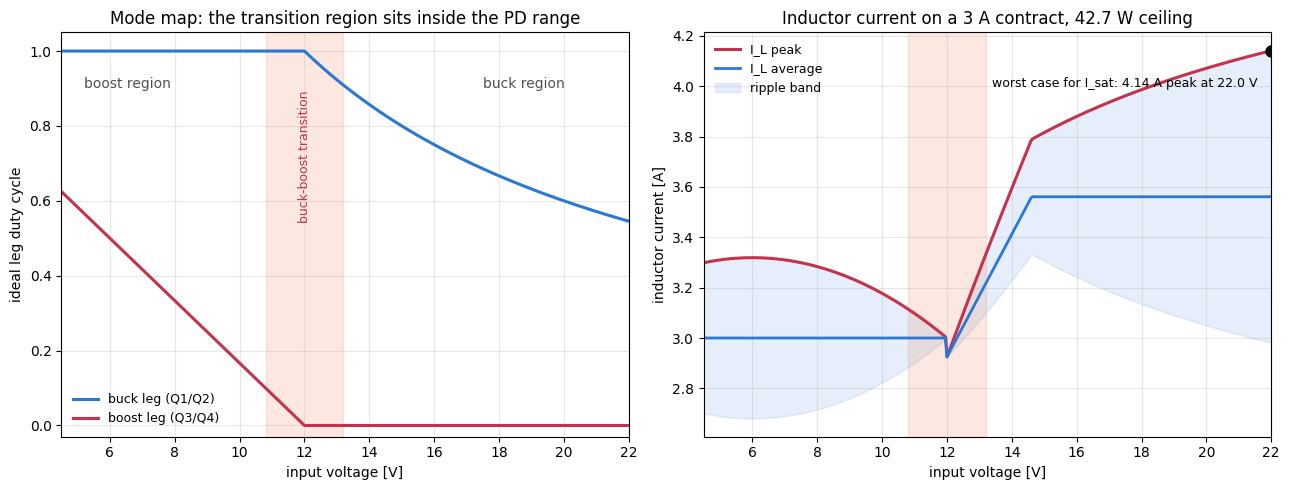

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# The two legs have separate duties. Plotting them as one curve would invent a
# discontinuity at 12 V that the converter does not have.
d_buck  = np.minimum(1.0, V_OUT / v_in)        # Q1/Q2 leg: 100 % on (pass-through) in boost
d_boost = np.maximum(0.0, 1.0 - v_in / V_OUT)  # Q3/Q4 leg: 0 % in buck
ax1.plot(v_in, d_buck,  lw=2.2, color='#2a78d6', label='buck leg (Q1/Q2)')
ax1.plot(v_in, d_boost, lw=2.2, color='#c4324b', label='boost leg (Q3/Q4)')
ax1.axvspan(V_OUT * 0.9, V_OUT * 1.1, color='#eb6834', alpha=0.15)
ax1.annotate('buck-boost transition', (V_OUT, 0.55), ha='center', fontsize=9,
             color='#c4324b', rotation=90)
ax1.annotate('boost region', (5.2, 0.9), fontsize=10, color='#52514e')
ax1.annotate('buck region', (17.5, 0.9), fontsize=10, color='#52514e')
ax1.set_xlabel('input voltage [V]'); ax1.set_ylabel('ideal leg duty cycle')
ax1.set_title('Mode map: the transition region sits inside the PD range')
ax1.legend(fontsize=9, frameon=False, loc='lower left')
ax1.set_xlim(V_IN_LO, V_IN_HI); ax1.set_ylim(-0.03, 1.05); ax1.grid(alpha=0.3)

ax2.plot(v_in, i_peak, lw=2.2, color='#c4324b', label='I_L peak')
ax2.plot(v_in, i_avg, lw=2.0, color='#2a78d6', label='I_L average')
ax2.fill_between(v_in, i_avg - di_pp / 2, i_peak, color='#2a78d6', alpha=0.12, label='ripple band')
ax2.axvspan(V_OUT * 0.9, V_OUT * 1.1, color='#eb6834', alpha=0.15)
ax2.plot([v_in[k_worst]], [i_peak[k_worst]], 'o', color='#0b0b0b', ms=8, zorder=5)
ax2.annotate(f'worst case for I_sat: {i_peak[k_worst]:.2f} A peak at {v_in[k_worst]:.1f} V',
             (v_in[k_worst], i_peak[k_worst]), textcoords='offset points', xytext=(-10, -26),
             ha='right', fontsize=9)
ax2.set_xlabel('input voltage [V]'); ax2.set_ylabel('inductor current [A]')
ax2.set_title(f'Inductor current on a 3 A contract, {LOAD_SIZING_W:.1f} W ceiling')
ax2.set_xlim(V_IN_LO, V_IN_HI); ax2.legend(fontsize=9, frameon=False); ax2.grid(alpha=0.3)

fig.tight_layout()
fig.savefig('../figures/01_mode_map_and_currents.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Power budget at the points that matter

A single full-load number is the wrong budget for this design, because the load spends
almost none of its time there. What follows is the **measured** loss at the three
mission-profile settings and at the Objective 1 corner, per input voltage. `loss` here is
everything between the input connector and the 12 V rail: the power stage, the sense
resistors, the controller's own quiescent draw, and the board copper.

In [6]:
def at_power(vin_nom, p_out_target):
    'Nearest measured bin on the run at vin_nom to a given output power.'
    act = runs[vin_nom]
    k = (act.P_out - p_out_target).abs().idxmin()
    return act.loc[k]

MISSION = [(33, 4.29, 'quiet / continuous', 0.95),
           (67, 14.01, 'high',              0.04),
           (100, 35.88, 'peak',             0.01)]

rows = []
for vin_nom in (5, 9, 15, 20):
    for pwm, p_target, label, duty in MISSION:
        act = runs[vin_nom]
        if p_target > act.P_out.max() * 1.02:
            rows.append({'V_in': vin_nom, 'setting': label, 'P_out_W': np.nan,
                         'eta': np.nan, 'loss_W': np.nan, 'note': 'beyond source limit'})
            continue
        r = at_power(vin_nom, p_target)
        rows.append({'V_in': vin_nom, 'setting': label, 'P_out_W': round(r.P_out, 2),
                     'eta': round(r.eta, 4), 'loss_W': round(r.P_in - r.P_out, 3), 'note': ''})
budget = pd.DataFrame(rows)
print("Measured loss at the mission-profile settings (2026-09-15 runs):\n")
print(budget.pivot(index='setting', columns='V_in', values=['eta', 'loss_W']).to_string())
print("\nBlank = the source cannot reach that setting on a 3 A contract.")

Measured loss at the mission-profile settings (2026-09-15 runs):

                       eta                         loss_W                     
V_in                    5       9       15      20     5      9      15     20
setting                                                                       
high                   NaN  0.9844  0.9870  0.9815    NaN  0.224  0.185  0.263
peak                   NaN     NaN  0.9847  0.9810    NaN    NaN  0.556  0.696
quiet / continuous  0.9684  0.9744  0.9698  0.9570   0.14  0.113  0.134  0.193

Blank = the source cannot reach that setting on a 3 A contract.


### Which PD voltage should the board negotiate?

The mission profile spends 95 % of its hours at the quiet setting, so the efficiency that
matters for lifetime energy is the one at ~4.3 W out, not the one on the peak of the
efficiency curve. Those are different voltages.

In [7]:
QUIET_W = 4.29
rows = []
for vin_nom in (5, 9, 15, 20):
    r = at_power(vin_nom, QUIET_W)
    rows.append({'V_in': vin_nom, 'P_out_W': round(r.P_out, 2), 'eta_quiet': round(r.eta, 4),
                 'loss_W': round(r.P_in - r.P_out, 4)})
q = pd.DataFrame(rows).sort_values('loss_W').reset_index(drop=True)
best, worst = q.iloc[0], q.iloc[-1]
hours_quiet = 0.95 * cfg.HOURS_PER_YEAR
q['kWh_per_yr_at_95pct'] = (q.loss_W * hours_quiet / 1000).round(2)
q['USD_per_yr'] = (q.kWh_per_yr_at_95pct * cfg.ELECTRICITY_USD_PER_KWH).round(3)
print("Converter loss at the quiet setting (95 % of hours), measured:")
print()
print(q.to_string(index=False))
print()
print(f"Best: {best.V_in:.0f} V ({best.eta_quiet:.3%}).  Worst: {worst.V_in:.0f} V ({worst.eta_quiet:.3%}).")
print(f"Difference: {1000*(worst.loss_W-best.loss_W):.0f} mW, or "
      f"${(worst.loss_W-best.loss_W)*hours_quiet/1000*cfg.ELECTRICITY_USD_PER_KWH:.2f}/yr "
      f"(${(worst.loss_W-best.loss_W)*hours_quiet/1000*cfg.ELECTRICITY_USD_PER_KWH*10:.2f} over 10 years).")
print()
print("Small in absolute terms - but it is a firmware choice in the PD negotiation, so it")
print("costs nothing to take. It also runs against the intuition that a higher input voltage")
print("is better: at 4.3 W out, 20 V is the worst of the four. Note the caveat in")
print("measurements/efficiency/README.md - below ~2 W the fan-rail offset limits efficiency")
print("precision to about +/-1.3 points, and 4.3 W is not far above that.")

Converter loss at the quiet setting (95 % of hours), measured:

 V_in  P_out_W  eta_quiet  loss_W  kWh_per_yr_at_95pct  USD_per_yr
    9     4.30     0.9744  0.1129                 0.94       0.188
   15     4.29     0.9698  0.1335                 1.11       0.222
    5     4.29     0.9684  0.1398                 1.16       0.232
   20     4.29     0.9570  0.1928                 1.60       0.320

Best: 9 V (97.440%).  Worst: 20 V (95.700%).
Difference: 80 mW, or $0.13/yr ($1.33 over 10 years).

Small in absolute terms - but it is a firmware choice in the PD negotiation, so it
costs nothing to take. It also runs against the intuition that a higher input voltage
is better: at 4.3 W out, 20 V is the worst of the four. Note the caveat in
measurements/efficiency/README.md - below ~2 W the fan-rail offset limits efficiency
precision to about +/-1.3 points, and 4.3 W is not far above that.


In [8]:
# The Objective 1 corner, straight from the 5 V run.
act5 = runs[5]; k = act5.P_in.idxmax()
p_in5, p_out5, eta5 = act5.loc[k, 'P_in'], act5.loc[k, 'P_out'], act5.loc[k, 'eta']
print("Objective 1 corner - 5 V source at its 3 A limit, as measured:")
print(f"  V_in {act5.loc[k,'in_V']:.2f} V   I_in {act5.loc[k,'in_A']:.2f} A   P_in {p_in5:.2f} W")
print(f"  P_out {p_out5:.2f} W   eta {eta5:.4f}   loss {p_in5-p_out5:.3f} W")
print(f"  of which the housekeeping buck consumes {HOUSEKEEPING_W:.2f} W of the output,")
print(f"  leaving {p_out5-HOUSEKEEPING_W:.2f} W for the fans = "
      f"{100*(p_out5-HOUSEKEEPING_W)/MEASURED_FANS_W:.0f} % of full-speed fan POWER,")
print(f"  which the notebook 00 load curve places at {act5.loc[k,'pwm_pct']:.0f} % PWM - power")
print("  fraction and speed fraction are not the same number.")
print("\n")

print("Where that 0.39 W goes, from the component notebooks at the 5 V / 3 A design point:")
print("  inductor  0.122 W   Wuerth 7443634700, REDEXPERT (notebook 03)")
print("  MOSFETs   0.136 W   BSC0902NSI x4 at 7.35 V gate drive (notebook 04)")
print("  ---------------------------------------------------------------")
print("  modeled   0.258 W   = 66 % of the measured loss")
print("  unexplained ~0.13 W  sense resistors, controller Iq, copper, gate-drive")
print("                       losses not in the model - see notebook 11, which puts the")
print("                       model at 68 % of measured loss in boost at ~3 A.\n")
print("That ~0.13 W gap is larger than the 14-84 mW part-to-part differences notebooks 03")
print("and 04 rank candidates on. Those rankings compare modeled terms, not board loss.")

Objective 1 corner - 5 V source at its 3 A limit, as measured:
  V_in 4.64 V   I_in 3.02 A   P_in 14.02 W
  P_out 13.63 W   eta 0.9720   loss 0.393 W
  of which the housekeeping buck consumes 0.44 W of the output,
  leaving 13.19 W for the fans = 37 % of full-speed fan POWER,
  which the notebook 00 load curve places at 64 % PWM - power
  fraction and speed fraction are not the same number.


Where that 0.39 W goes, from the component notebooks at the 5 V / 3 A design point:
  inductor  0.122 W   Wuerth 7443634700, REDEXPERT (notebook 03)
  MOSFETs   0.136 W   BSC0902NSI x4 at 7.35 V gate drive (notebook 04)
  ---------------------------------------------------------------
  modeled   0.258 W   = 66 % of the measured loss
  unexplained ~0.13 W  sense resistors, controller Iq, copper, gate-drive
                       losses not in the model - see notebook 11, which puts the
                       model at 68 % of measured loss in boost at ~3 A.

That ~0.13 W gap is larger than the 14-8

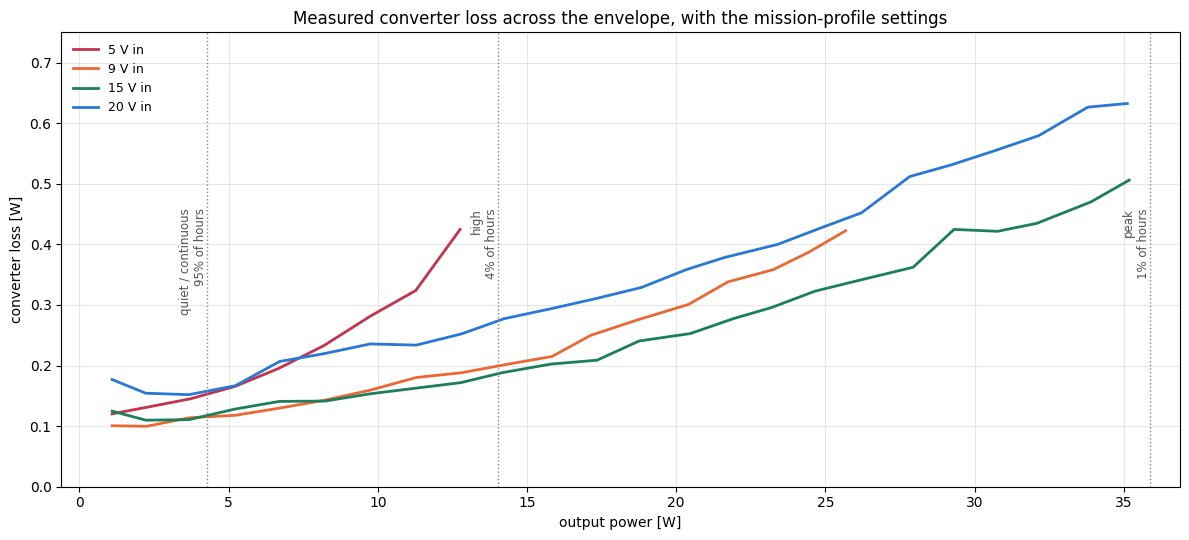

In [9]:
fig, ax = plt.subplots(figsize=(12, 5.5))
colors = {5: '#c4324b', 9: '#eb6834', 15: '#1b7f5a', 20: '#2a78d6'}
for v, act in runs.items():
    b = act.groupby(pd.cut(act.P_out, np.arange(0, 40, 1.5)), observed=True).agg(
        P=('P_out', 'mean'), loss=('P_in', 'mean'), n=('P_out', 'size'), po=('P_out', 'mean'))
    b = b[b.n >= 4]
    ax.plot(b.P, b.loss - b.po, lw=2, color=colors[v], label=f'{v} V in')
for pwm, p_target, label, duty in MISSION:
    ax.axvline(p_target, color='#898781', lw=1, ls=':')
    ax.annotate(f'{label}\n{duty:.0%} of hours', (p_target, 0.46), rotation=90, fontsize=8.5,
                color='#52514e', ha='right', va='top')
ax.set_xlabel('output power [W]'); ax.set_ylabel('converter loss [W]')
ax.set_title('Measured converter loss across the envelope, with the mission-profile settings')
ax.set_ylim(0, 0.75); ax.legend(fontsize=9, frameon=False, loc='upper left'); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('../figures/01_loss_vs_output.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. An envelope constraint that is not steady-state

All ten fans share one PWM signal, so they start together. On 2026-09-15 that simultaneous
start tripped the 3 A input limit in three consecutive attempts at ~6 % PWM: one 282 ms
reading showed 3.82 A nominal input (≈ 3.4 A calibrated — the true peak inside the window is
higher) before the ramp reversed. A successful run only differed in that the surge happened
to split across two readings.

This is a real envelope constraint at 5 V that steady-state power budgeting does not show:
**the worst input current is a startup transient, not a full-load operating point.** It is
a firmware problem with a firmware fix — stagger the fan starts across the ten PWM pins —
and it is not fixed on V1. Details and the logger change in
`measurements/efficiency/README.md`.

## Final Conclusions

**The envelope has one interesting feature and it sets the whole optimization.** On a 3 A
contract the source/load crossover is at **14.6 V** against the 42.7 W nameplate (12.3 V
against the 35.9 W measured load). Below it the converter is input-power-starved and every
milliwatt of loss subtracts from fan speed; above it the source has power to spare and loss
only costs electricity. That is why Objective 1 optimizes 5 V / 3 A and why 9/15/20 V are
checked rather than optimized.

**The binding corner measures 97.2 %.** At 4.64 V and 3.02 A in, the board delivers 13.63 W
to the 12 V rail for 0.39 W of loss. Notebooks 03 and 04 account for 0.258 W of that; the
remaining ~0.13 W is not in any model in this repo (notebook 11 sizes it across the whole
envelope). The unexplained remainder is larger than the part-to-part differences those
notebooks rank on, which bounds how much weight their rankings deserve.

**Worst-case inductor current is at the top of the input range, not the bottom.** In buck
the inductor carries the output current, so 22 V in at the nameplate load gives 3.56 A
average plus 1.16 A pk-pk of ripple — **4.14 A peak**. The boost corner is milder: the 3 A
input limit holds the inductor at 3.0 A average, 3.30 A peak. Notebook 03 sizes I_sat
against the high-voltage corner. Because the sizing load is 19 % above the measured load,
that margin is larger in practice than the number claims.

**Sizing keeps the nameplate; analysis uses the measurement.** Notebooks 03–06 continue to
size against 42.7 W, which errs conservative. The measured 35.9 W matters for Objective 2,
where it is the mission-profile weighting rather than a margin, and it is applied there
(notebook 00, then 09).

**For the mission profile, negotiate 9 V.** At the quiet setting where 95 % of the hours
are spent, measured converter loss is lowest at 9 V and highest at 20 V. The saving is
fractions of a dollar a year, but it is a firmware choice in the PD negotiation rather than
a part cost, so there is no reason not to take it. It is also the opposite of the intuition
that a higher input voltage is always better — that intuition holds at the top of the
efficiency curve, not at 4.3 W out.

**Two items this notebook does not settle.** The startup surge above is unfixed on V1 and
needs firmware. And `constants.C_OUT_ESR_OHMS` (12.6 mΩ) does not match the 18.3 mΩ that
notebook 05 computes from the same dissipation factor — the constant omits a factor that
the notebooks apply. Nothing currently imports the constant, so no result in the repo is
affected, but the two should be reconciled in notebook 05, which owns that calculation.